# Task 4: Pick the Right Chart, Five Times (mpg.csv)

We will analyze a dataset of 398 cars from 1970–1982 to answer five specific questions with appropriate visualizations and justifications. We will also redraw the weakest chart to improve it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset. If not locally available, we can load it from a common online repository.
try:
    df = pd.read_csv('mpg.csv')
except FileNotFoundError:
    url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv'
    df = pd.read_csv(url)

# Check the dataset shape and columns
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### Q1: Did cars get more fuel-efficient between 1970 and 1982?

**Chart Choice:** Line Plot (with error bands or confidence intervals) / Boxplot by year.

*Justification:* A line plot showing the average mpg per year with a confidence interval is ideal for tracking the continuous trend of a metric over time.

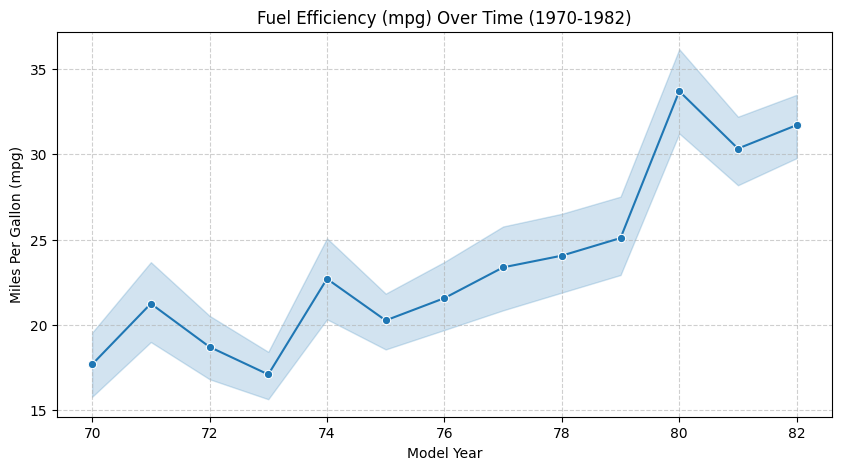

In [2]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='model_year', y='mpg', marker='o')
plt.title('Fuel Efficiency (mpg) Over Time (1970-1982)')
plt.xlabel('Model Year')
plt.ylabel('Miles Per Gallon (mpg)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Q2: Do American, European and Japanese cars differ in fuel efficiency?

**Chart Choice:** Boxplot.

*Justification:* A boxplot is excellent for comparing the distribution, medians, and spread of a continuous variable (mpg) across different categorical groups (origins).

/tmp/ipykernel_951/364983974.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='origin', y='mpg', palette='Set2')


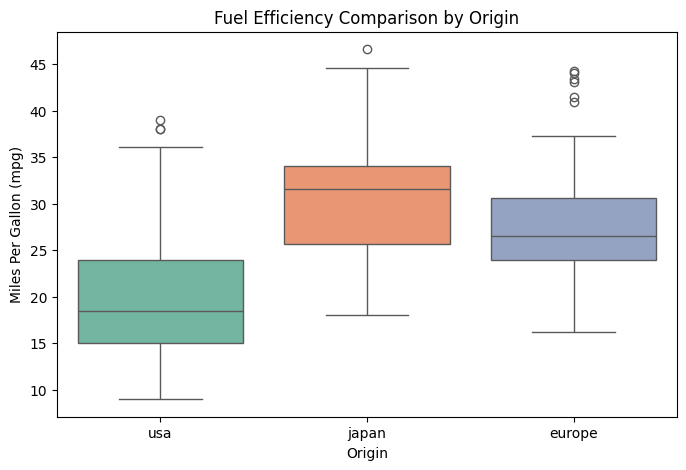

In [3]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='origin', y='mpg', palette='Set2')
plt.title('Fuel Efficiency Comparison by Origin')
plt.xlabel('Origin')
plt.ylabel('Miles Per Gallon (mpg)')
plt.show()

### Q3: What is the relationship between a car's weight and its fuel efficiency?

**Chart Choice:** Scatter Plot.

*Justification:* A scatter plot is the standard and most effective chart to visualize the correlation and relationship between two continuous variables (weight and mpg).

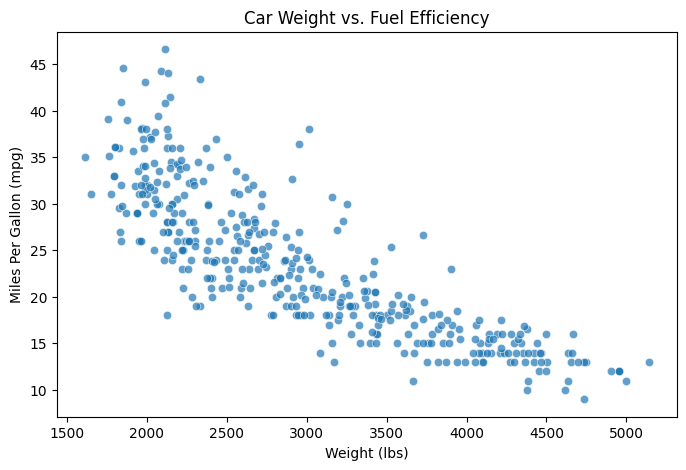

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='weight', y='mpg', alpha=0.7)
plt.title('Car Weight vs. Fuel Efficiency')
plt.xlabel('Weight (lbs)')
plt.ylabel('Miles Per Gallon (mpg)')
plt.show()

### Q4: How is the number of cylinders distributed across the fleet?

**Chart Choice:** Bar Chart (Count Plot).

*Justification:* Since the number of cylinders acts as a discrete categorical/ordinal value, a bar chart of counts is the best way to show the frequency of each specific category.

/tmp/ipykernel_951/1706625882.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='cylinders', palette='viridis')


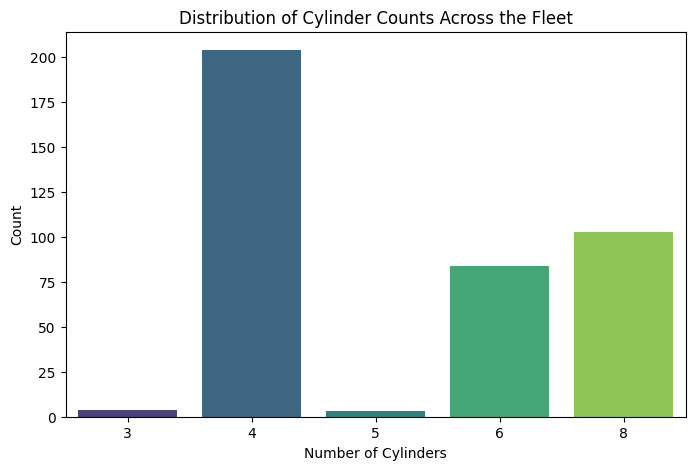

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='cylinders', palette='viridis')
plt.title('Distribution of Cylinder Counts Across the Fleet')
plt.xlabel('Number of Cylinders')
plt.ylabel('Count')
plt.show()

### Q5: Is the improvement in question 1 explained by question 3? (i.e. did cars get lighter?)

**Chart Choice:** Dual-axis or faceted line/scatter plot over years.

*Justification:* To see if weight changes explain the fuel efficiency changes over time, we plot the average car weight per year using a line plot to compare directly with the Q1 trend.

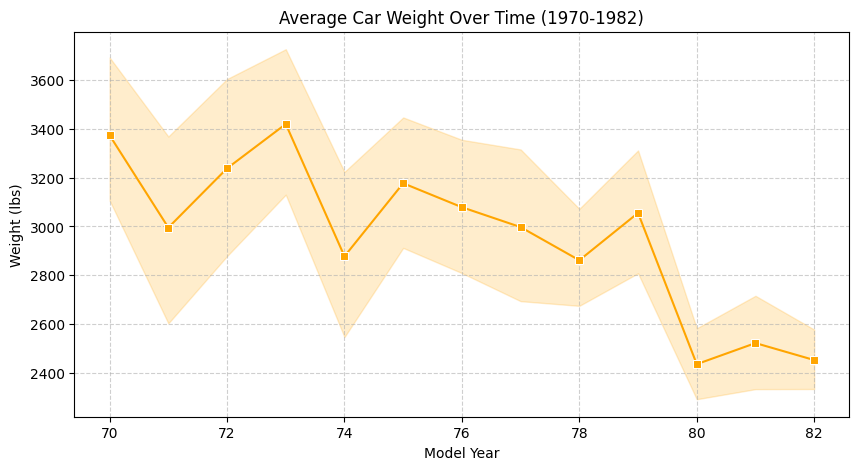

In [6]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='model_year', y='weight', marker='s', color='orange')
plt.title('Average Car Weight Over Time (1970-1982)')
plt.xlabel('Model Year')
plt.ylabel('Weight (lbs)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Redrawing the Weakest Chart

**Weakest Chart:** Question 5 (Separate line plot for weight over time).

*What we changed:* Instead of analyzing weight in isolation or forcing the user to mentally overlay Q1 and Q5, we will plot both `mpg` and `weight` normalized, or use a scatter plot of weight vs mpg colored by year, or a dual-axis line chart to clearly demonstrate the direct co-evolution of weight reduction and MPG improvement over the years.

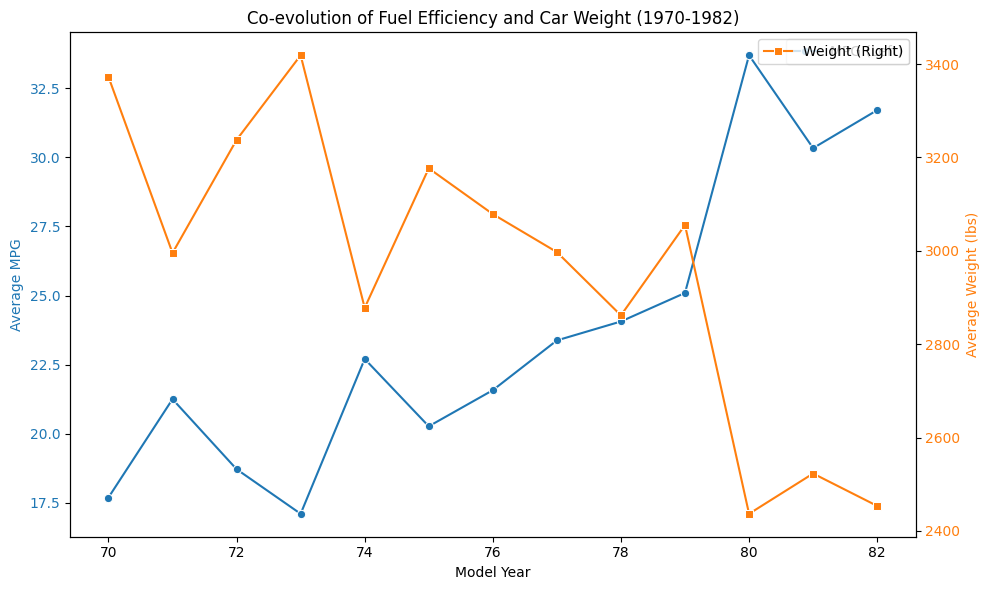

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Model Year')
ax1.set_ylabel('Average MPG', color=color)
sns.lineplot(data=df, x='model_year', y='mpg', ax=ax1, color=color, marker='o', label='MPG (Left)', errorbar=None)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Average Weight (lbs)', color=color)
sns.lineplot(data=df, x='model_year', y='weight', ax=ax2, color=color, marker='s', label='Weight (Right)', errorbar=None)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Co-evolution of Fuel Efficiency and Car Weight (1970-1982)')
fig.tight_layout()
plt.show()